# 🗣️ Whisper Mispronunciation Detection — Speechocean762
Task: Predict per-word accuracy (0–10) from audio
Option A: Whisper encoder + regression head

In [1]:
!pip install -q openai-whisper evaluate torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 38.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.9 MB/s

In [2]:
import os, json, torch, whisper, evaluate, numpy as np, pandas as pd
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torch import nn
from tqdm import tqdm
from pathlib import Path

2025-10-19 17:42:38.262923: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760895758.456250      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760895758.508263      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# =========================================================
# 1️⃣ Setup
# =========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
DATA_ROOT = Path("/kaggle/input/speechocean762")
MODEL_NAME = "small.en"

In [5]:
os.makedirs("/kaggle/working/whisper-mispronunciation", exist_ok=True)
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [6]:
# =========================================================
# 2️⃣ Load scores.json
# =========================================================
score_path = DATA_ROOT / "resource" / "scores.json"
with open(score_path, "r") as f:
    scores = json.load(f)

# Each entry example:
# { "utt_id": { "accuracy": 7.8, "completeness": 8.1, ... , "words": [{"text":"WHAT","accuracy":7.2}, ...] } }

In [7]:
# =========================================================
# 3️⃣ Load split file  — with downsample of accuracy=10
# =========================================================
def load_split(split_name="train"):
    split_dir = DATA_ROOT / split_name
    wav_scp = split_dir / "wav.scp"

    wav_map = {}
    with open(wav_scp, "r") as f:
        for line in f:
            utt, rel_path = line.strip().split(maxsplit=1)
            wav_map[utt] = DATA_ROOT / rel_path

    data = []
    for utt, wav_path in wav_map.items():
        if utt in scores:
            s = scores[utt]
            for w in s["words"]:
                data.append({
                    "utt_id": utt,
                    "wav": wav_path,
                    "word": w["text"],
                    "accuracy": float(w["accuracy"])
                })

    # Convert to DataFrame for sampling
    import pandas as pd, numpy as np
    df = pd.DataFrame(data)

    # Separate 10s and <10s
    df_10 = df[df["accuracy"] == 10]
    df_not10 = df[df["accuracy"] < 10]
    
    # Keep only 20% of perfect samples
    if len(df_10) > 0:
        df_10 = df_10.sample(frac=0.2, random_state=42)
    
    df = pd.concat([df_not10, df_10]).sample(frac=1, random_state=42).reset_index(drop=True)

    return df.to_dict(orient="records")

# =========================================================
# Reload train/test splits
# =========================================================
train_data = load_split("train")
test_data  = load_split("test")

print(f"✅ Train words: {len(train_data)} | Test words: {len(test_data)}")

✅ Train words: 4697 | Test words: 4512


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def show_data_distribution(data):
    # Convert list of dicts → DataFrame
    df = pd.DataFrame(data)
    
    # =========================================================
    # Summary statistics
    # =========================================================
    print("\n=== Summary Statistics ===")
    print(df["accuracy"].describe())
    
    # =========================================================
    # Plot 1: Accuracy distribution histogram
    # =========================================================
    plt.figure(figsize=(7, 4))
    sns.histplot(df["accuracy"], bins=11, kde=True)
    plt.title("Distribution of Word-Level Accuracy Scores")
    plt.xlabel("Accuracy (0-10)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()
    
    # =========================================================
    # Plot 2: Top 20 most frequent words
    # =========================================================
    plt.figure(figsize=(8, 5))
    top_words = df["word"].value_counts().head(20)
    sns.barplot(x=top_words.values, y=top_words.index, palette="viridis")
    plt.title("Top 20 Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.grid(alpha=0.3)
    plt.show()
    
    # =========================================================
    # Plot 3: Average accuracy per word (Top 20)
    # =========================================================
    plt.figure(figsize=(8, 5))
    mean_acc = df.groupby("word")["accuracy"].mean().sort_values(ascending=False).head(20)
    sns.barplot(x=mean_acc.values, y=mean_acc.index, palette="mako")
    plt.title("Top 20 Words by Average Pronunciation Accuracy")
    plt.xlabel("Mean Accuracy")
    plt.ylabel("Word")
    plt.grid(alpha=0.3)
    plt.show()


=== Summary Statistics ===
count    4697.000000
mean        7.702363
std         3.041238
min         0.000000
25%         5.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: accuracy, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


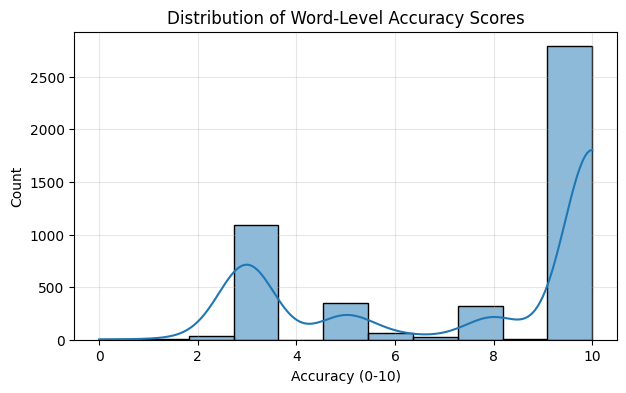

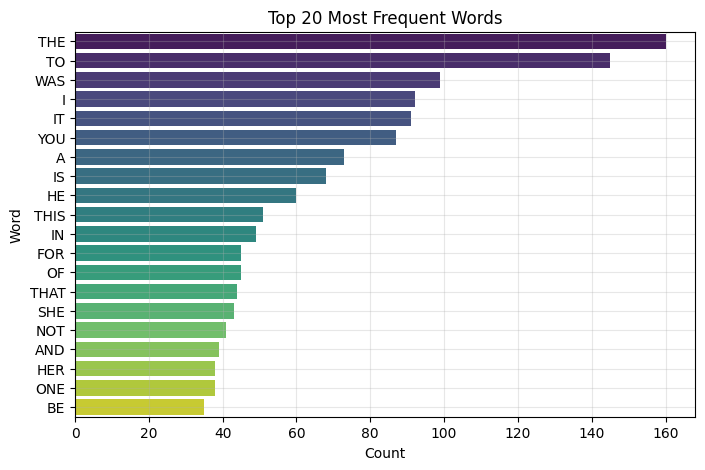

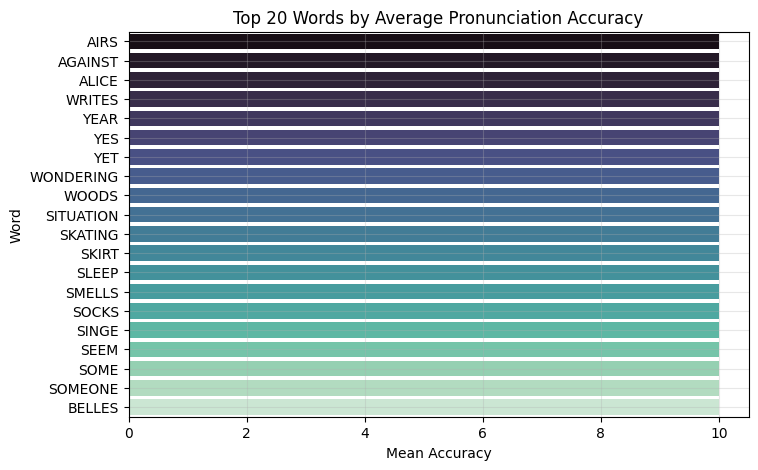

In [9]:
show_data_distribution(train_data)


=== Summary Statistics ===
count    4512.000000
mean        8.005984
std         2.914386
min         0.000000
25%         5.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: accuracy, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


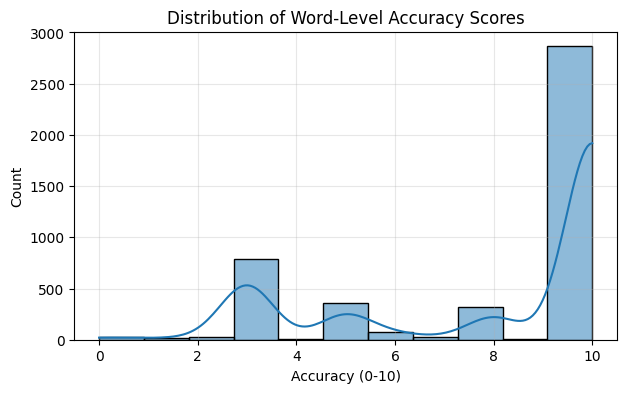

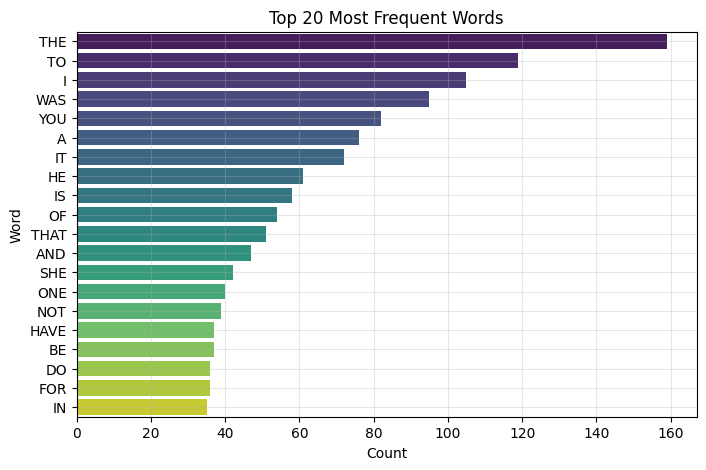

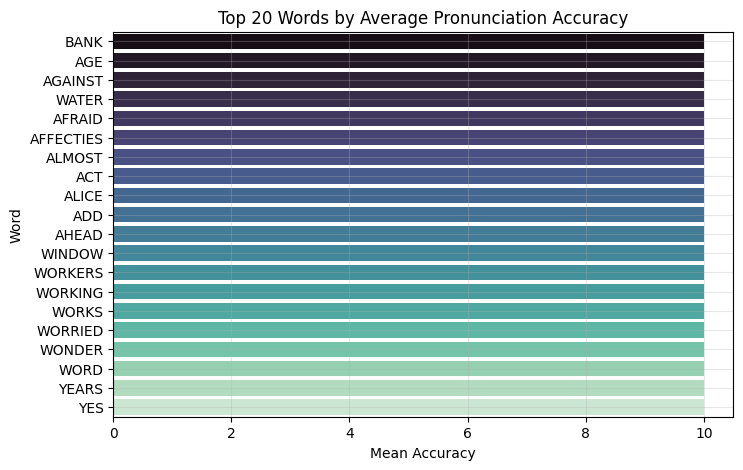

In [10]:
show_data_distribution(test_data)

In [11]:
# =========================================================
# 4️⃣ Dataset
# =========================================================
class SpeechOceanWordDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d = self.data[idx]
        wav, sr = torchaudio.load(d["wav"])
        if sr != 16000:
            wav = torchaudio.functional.resample(wav, sr, 16000)
        wav = wav.mean(dim=0, keepdim=True)

        MAX_LEN = 20 * 16000
        wav = wav[:, :MAX_LEN]
        if wav.shape[1] < MAX_LEN:
            wav = torch.nn.functional.pad(wav, (0, MAX_LEN - wav.shape[1]))

        mel = whisper.log_mel_spectrogram(wav[0])
        return mel, torch.tensor([d["accuracy"]], dtype=torch.float32), d["word"], d["utt_id"]

In [12]:
# =========================================================
# 5️⃣ Model
# =========================================================
from whisper.audio import pad_or_trim

class WhisperWordRegressor(nn.Module):
    def __init__(self, model_name="small.en", freeze_n=8):
        super().__init__()
        self.whisper = whisper.load_model(model_name)
        for i, blk in enumerate(self.whisper.encoder.blocks):
            if i < freeze_n:
                for p in blk.parameters(): p.requires_grad = False

        dim = self.whisper.encoder.blocks[0].attn.key.weight.shape[1]
        self.head = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim // 2, 1),
            nn.Sigmoid()   # output in [0, 1]
        )

    def forward(self, mel):
        if mel.ndim == 3:
            mel = mel.squeeze(1)
        # ✅ ensure fixed length
        mel = pad_or_trim(mel, 3000)
        enc = self.whisper.encoder(mel.to(next(self.parameters()).device))
        pooled = enc.mean(dim=1)
        return self.head(pooled) * 10.0

In [13]:
# =========================================================
# 6️⃣ Dataloaders
# =========================================================
train_ds = SpeechOceanWordDataset(train_data)
test_ds  = SpeechOceanWordDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=4, shuffle=False)

In [14]:
# =========================================================
# 7️⃣ Training setup
# =========================================================
model = WhisperWordRegressor(MODEL_NAME).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=5e-6)

100%|███████████████████████████████████████| 461M/461M [00:52<00:00, 9.19MiB/s]


In [15]:
def weighted_l1_loss(pred, target):
    # define per-sample weight: higher weight for low scores (rare)
    weights = 1.0 / (1.0 + torch.exp((target - 5.0)))  # sigmoid shape
    weights = weights / weights.mean()  # normalize

    loss = torch.abs(pred - target) * weights
    return loss.mean()

In [16]:
loss_fn = weighted_l1_loss

NUM_EPOCHS = 10
best_val = float("inf")

In [17]:
# =========================================================
# 8️⃣ Training loop
# =========================================================
for epoch in range(NUM_EPOCHS):
    model.train()
    tr_loss = 0
    for mel, acc, _, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        mel, acc = mel.to(device), acc.to(device)
        opt.zero_grad()
        pred = model(mel)
        loss = loss_fn(pred, acc)
        loss.backward()
        opt.step()
        tr_loss += loss.item()
    tr_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for mel, acc, _, _ in test_loader:
            mel, acc = mel.to(device), acc.to(device)
            pred = model(mel)
            val_loss += loss_fn(pred, acc).item()
    val_loss /= len(test_loader)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train MAE: {tr_loss:.4f} | Val MAE: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "/kaggle/working/whisper-mispronunciation/best_model.pth")
        print("✅ Saved best model.")

Epoch 1/10: 100%|██████████| 1175/1175 [17:53<00:00,  1.09it/s]


Epoch 1/10 | Train MAE: 1.6387 | Val MAE: 2.0338
✅ Saved best model.


Epoch 2/10: 100%|██████████| 1175/1175 [17:31<00:00,  1.12it/s]


Epoch 2/10 | Train MAE: 1.3617 | Val MAE: 2.0119
✅ Saved best model.


Epoch 3/10: 100%|██████████| 1175/1175 [17:31<00:00,  1.12it/s]


...

Epoch 8/10 | Train MAE: 0.9000 | Val MAE: 2.0072


Epoch 9/10: 100%|██████████| 1175/1175 [17:25<00:00,  1.12it/s]


Epoch 9/10 | Train MAE: 0.8719 | Val MAE: 1.9779


Epoch 10/10: 100%|██████████| 1175/1175 [17:22<00:00,  1.13it/s]


Epoch 10/10 | Train MAE: 0.8715 | Val MAE: 2.1856


In [18]:
# =========================================================
# 9️⃣ Evaluation
# =========================================================
model.load_state_dict(torch.load("/kaggle/working/whisper-mispronunciation/best_model.pth"))
model.eval()

predictions = []
y_true, y_pred = [], []

with torch.no_grad():
    for mel, acc, word, utt in tqdm(test_loader, desc="Evaluating"):
        mel, acc = mel.to(device), acc.to(device)
        pred = model(mel)
        y_true.extend(acc.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())
        for w, p, t, u in zip(word, pred.cpu().numpy().flatten(), acc.cpu().numpy().flatten(), utt):
            predictions.append({
                "utt_id": u,
                "word": w,
                "pred_accuracy": round(float(p), 3),
                "true_accuracy": round(float(t), 3)
            })

Evaluating: 100%|██████████| 1128/1128 [05:41<00:00,  3.30it/s]


In [19]:
# =========================================================
# Save JSON outputs
# =========================================================
out_path = "/kaggle/working/whisper-mispronunciation/predictions.json"
with open(out_path, "w") as f:
    json.dump({"words": predictions}, f, indent=2)
print(f"💾 Saved predictions to {out_path}")

💾 Saved predictions to /kaggle/working/whisper-mispronunciation/predictions.json


In [20]:
# =========================================================
# Metrics
# =========================================================
metric_corr = evaluate.load("pearsonr")
mae = np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

In [21]:
corr = metric_corr.compute(
    predictions=np.array(y_pred).flatten(),
    references=np.array(y_true).flatten()
)["pearsonr"]

In [22]:
print(f"\n✅ Overall MAE: {mae:.4f} | Pearson r: {corr:.4f}")

# Top 5 hardest samples
errors = sorted(predictions, key=lambda x: abs(x["pred_accuracy"] - x["true_accuracy"]), reverse=True)
print("\nTop 5 mispredicted words:")
for e in errors[:5]:
    print(f"[{e['word']}] pred={e['pred_accuracy']} true={e['true_accuracy']} utt={e['utt_id']}")


✅ Overall MAE: 2.6626 | Pearson r: 0.4475

Top 5 mispredicted words:
[THEY] pred=8.19 true=0.0 utt=069020059
[NOT] pred=8.19 true=0.0 utt=069020059
[DID] pred=8.19 true=0.0 utt=069020059
[MORE] pred=8.19 true=0.0 utt=069020059
[SEE] pred=8.19 true=0.0 utt=069020059
